# Dense Retrieval of arXiv Papers with BGE and FAISS

## Objective

Build a dense retrieval system that returns the most relevant arXiv papers for a natural-language query. Documents consist of paper titles and abstracts. Each evaluation query has one known relevant arXiv identifier.

## Evaluation target

The target metric is **Mean Reciprocal Rank at 5 (MRR@5) > 0.91**. The system is also profiled at query level to separate encoder inference, FAISS retrieval, and result-materialisation latency.

## Scope

This notebook implements **document retrieval**, not question answering, RAG, paper recommendation, or generated scientific advice. It returns a ranked list of paper identifiers, titles, and similarity scores from a fixed collection.

> **Google Colab note.** The input archive remains on Google Drive because it is large. The notebook uses the existing Drive paths deliberately. It does not upload the archive, raw metadata, embeddings, or FAISS index to GitHub.


In [ ]:
# Run this cell in a fresh Google Colab runtime.
# A CPU FAISS index is used deliberately so that the recorded benchmark is explicit.
%pip install -q -U "transformers>=4.45" "faiss-cpu>=1.8.0"


In [ ]:
import gc
import importlib.metadata
import json
import os
import random
import shutil
import sys
import time
import zipfile
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from google.colab import drive
from transformers import AutoModel, AutoTokenizer

SEED = 42
EMBEDDER_NAME = 'BAAI/bge-base-en-v1.5'
MAX_LENGTH = 512
QUERY_INSTRUCTION = 'Represent this sentence for searching relevant passages: '

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Load the course archive from Google Drive

The two paths below are intentionally retained from the original Colab workflow. Change only `ZIP_PATH` if the archive has a different name or location in your Drive. The extracted data are stored in the temporary Colab runtime. Derived embeddings and the FAISS index are saved back to Drive so that they can be re-used after a runtime restart.


In [ ]:
drive.mount('/content/drive', force_remount=False)

# Keep the original Google Drive location for the large course archive.
ZIP_PATH = Path('/content/drive/MyDrive/nlp_s3_data.zip')
DATA_DIR = Path('/content/arxiv_data')
DATA_SUBDIR = DATA_DIR / 'nlp_s3_project'

# Derived artifacts are stored outside the Git repository.
ARTIFACT_DIR = Path('/content/drive/MyDrive/arxiv_retrieval')
EMBEDDINGS_PATH = ARTIFACT_DIR / 'article_embeddings_cls.npy'
FAISS_INDEX_PATH = ARTIFACT_DIR / 'faiss_index_cls.bin'

if not ZIP_PATH.is_file():
    raise FileNotFoundError(
        f'Course archive not found: {ZIP_PATH}. Update ZIP_PATH to the archive location in Google Drive.'
    )

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# The archive is supplied through the course workflow and is treated as a trusted local input.
# Re-extract only when the expected directory is missing, unless a clean extraction is required.
FORCE_EXTRACT = False

if FORCE_EXTRACT and DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
    DATA_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_SUBDIR.exists():
    with zipfile.ZipFile(ZIP_PATH, 'r') as archive:
        archive.extractall(DATA_DIR)

expected_files = [
    DATA_SUBDIR / 'arxiv-metadata-s.json',
    DATA_SUBDIR / 'test_sample.csv',
]
missing_files = [path for path in expected_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f'Archive was extracted but expected files are missing: {missing_files}')

## Stage 1 - Exploratory data analysis


In [5]:
with (DATA_SUBDIR / 'arxiv-metadata-s.json').open(encoding='utf-8') as file:
    articles_raw = json.load(file)

articles_df = pd.DataFrame(articles_raw)[['id', 'title', 'abstract']].copy()
test_df = pd.read_csv(DATA_SUBDIR / 'test_sample.csv', dtype={'id': 'string'})

# Input validation and stable text fields.
articles_df['id'] = articles_df['id'].astype('string')
test_df['id'] = test_df['id'].astype('string')
for column in ['title', 'abstract']:
    articles_df[column] = articles_df[column].fillna('').astype(str)
for column in ['query', 'abstract']:
    if column in test_df.columns:
        test_df[column] = test_df[column].fillna('').astype(str)

required_test_columns = {'id', 'query'}
missing_test_columns = required_test_columns - set(test_df.columns)
if missing_test_columns:
    raise ValueError(f'Missing required evaluation columns: {missing_test_columns}')
if not articles_df['id'].is_unique:
    raise ValueError('Article identifiers must be unique before indexing.')

missing_target_ids = set(test_df['id']) - set(articles_df['id'])
if missing_target_ids:
    raise ValueError(f'{len(missing_target_ids)} evaluation IDs are absent from the article collection.')

print(f'Articles in the collection: {len(articles_df):,}')
print(f'Evaluation queries: {len(test_df):,}')
print(f'Target IDs missing from the collection: {len(missing_target_ids):,}')
display(articles_df.head(3))
display(test_df.head(3))


Articles in the collection: 98,213
Evaluation queries: 1,000
Target IDs missing from the collection: 0


,id,title,abstract
0,0704.0038,The discrete dipole approximation: an overview...,We present a review of the discrete dipole a...
1,0704.0057,High-spin to low-spin and orbital polarization...,We study the interplay of crystal field spli...
2,0704.0060,Coulomb excitation of unstable nuclei at inter...,We investigate the Coulomb excitation of low...


,id,abstract,query
0,2412.16732,A new platinate was recently discovered when...,What unique composition and decomposition beha...
1,nucl-th/9602019,The production cross sections of various fra...,How does the inclusion of statistical decay af...
2,2501.05500,This survey provides a comprehensive examina...,What are the core components of modern zero-kn...


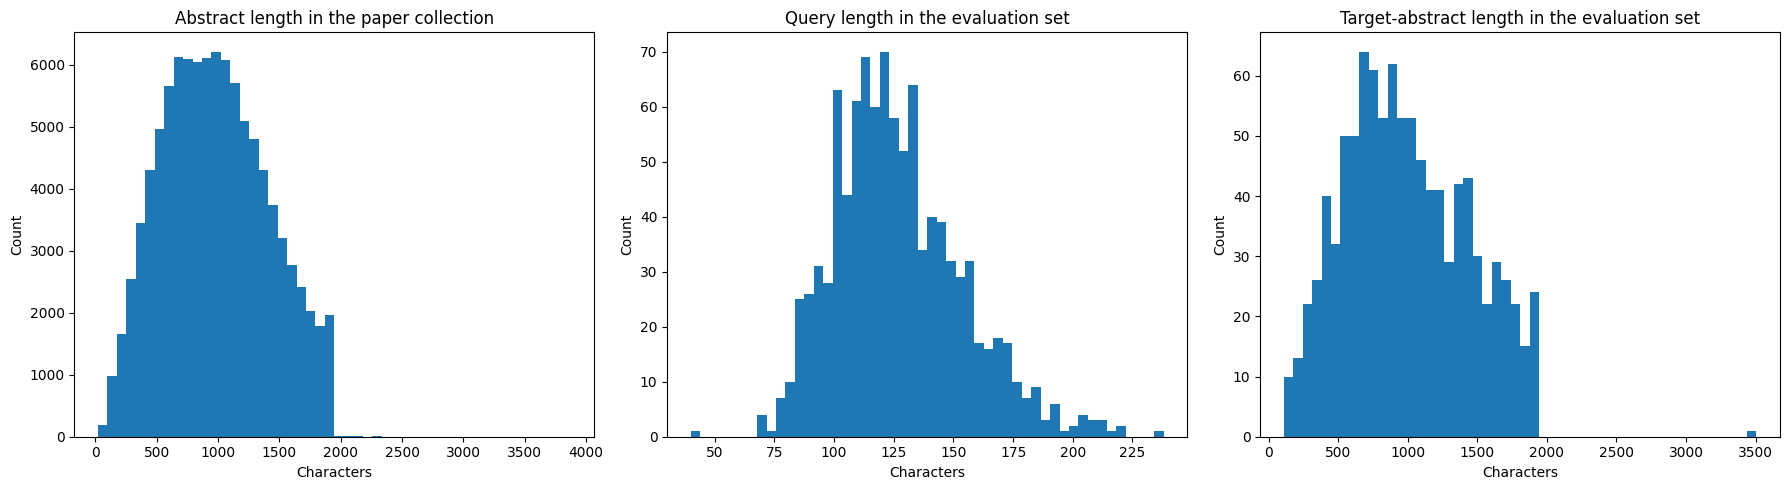

Collection abstract-length summary:


,count,mean,std,min,25%,50%,75%,max
abstract_characters,98213.0,981.934174,431.635951,21.0,648.0,958.0,1294.0,3874.0


Evaluation query-length summary:


,count,mean,std,min,25%,50%,75%,max
query_characters,1000.0,126.886,26.951909,40.0,108.0,123.5,143.0,238.0



Example evaluation queries:
Query: What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?
Target abstract (first 150 characters):   A new platinate was recently discovered when Nd2O3 was explored as a platinum
capture material in the Ostwald process, formed by a direct reaction b...

Query: How does the inclusion of statistical decay affect the shape of mass and charge distributions in quantum molecular dynamics simulations?
Target abstract (first 150 characters):   The production cross sections of various fragments from proton-induced
reactions on $^{56}$Fe and $^{27}$Al have been analyzed by the Quantum
Molecu...

Query: What are the core components of modern zero-knowledge proofs discussed in the context of verifiable computing?
Target abstract (first 150 characters):   This survey provides a comprehensive examination of verifiable computing,
tracing its evolution from foundational complexity theory to 

In [6]:
articles_df['abstract_characters'] = articles_df['abstract'].str.len()
test_df['query_characters'] = test_df['query'].str.len()
if 'abstract' in test_df.columns:
    test_df['target_abstract_characters'] = test_df['abstract'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(articles_df['abstract_characters'], bins=50)
axes[0].set(title='Abstract length in the paper collection', xlabel='Characters', ylabel='Count')

axes[1].hist(test_df['query_characters'], bins=50)
axes[1].set(title='Query length in the evaluation set', xlabel='Characters', ylabel='Count')

if 'target_abstract_characters' in test_df.columns:
    axes[2].hist(test_df['target_abstract_characters'], bins=50)
    axes[2].set(title='Target-abstract length in the evaluation set', xlabel='Characters', ylabel='Count')
else:
    axes[2].axis('off')

plt.tight_layout()
plt.show()

print('Collection abstract-length summary:')
display(articles_df['abstract_characters'].describe().to_frame().T)
print('Evaluation query-length summary:')
display(test_df['query_characters'].describe().to_frame().T)

print('\nExample evaluation queries:')
for _, row in test_df.head(5).iterrows():
    print(f"Query: {row['query']}")
    if 'abstract' in test_df.columns:
        print(f"Target abstract (first 150 characters): {row['abstract'][:150]}...")
    print()


## EDA interpretation

The collection consists of long scientific abstracts and short natural-language queries. This is an **asymmetric retrieval** setting: each query is much shorter than its candidate documents. The observed paraphrasing between questions and abstracts motivates a dense-retrieval baseline. This notebook does **not** empirically compare dense retrieval with BM25 or TF-IDF, so it does not claim that a sparse baseline would necessarily be weaker.


## Stage 2 - Build the dense-retrieval index

`BAAI/bge-base-en-v1.5` is used because documents and queries are in English. For short-query-to-passage retrieval, the BGE documentation recommends adding an instruction to queries but not to passages. This notebook uses the documented **CLS-token embedding** (`last_hidden_state[:, 0]`) and L2-normalisation. With normalised vectors, inner-product ranking in `faiss.IndexFlatIP` is cosine-similarity ranking.


In [ ]:
embedder_tokenizer = AutoTokenizer.from_pretrained(EMBEDDER_NAME)
embedder_model = AutoModel.from_pretrained(EMBEDDER_NAME).to(device)
embedder_model.eval()

@torch.inference_mode()
def get_embeddings(texts, batch_size: int = 32, is_query: bool = False) -> np.ndarray:
    """Encode a non-empty list of texts with canonical BGE CLS pooling."""
    if not texts:
        raise ValueError('get_embeddings requires at least one text.')

    prepared_texts = [QUERY_INSTRUCTION + text for text in texts] if is_query else list(texts)
    batches = []

    for start_index in range(0, len(prepared_texts), batch_size):
        batch = prepared_texts[start_index:start_index + batch_size]
        inputs = embedder_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='pt',
        ).to(device)
        outputs = embedder_model(**inputs)

        # Canonical pooling from the BGE model card for direct Transformers use.
        embeddings = outputs.last_hidden_state[:, 0]
        embeddings = F.normalize(embeddings, p=2, dim=1)
        batches.append(embeddings.cpu().numpy().astype('float32'))

    return np.concatenate(batches, axis=0)

def package_version(name: str) -> str:
    try:
        return importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        return 'not installed as a Python distribution'

print(f'Embedding model: {EMBEDDER_NAME}')
print(f'Device: {device}')
print(f'torch: {torch.__version__}')
print(f'transformers: {package_version("transformers")}')
print(f'faiss: {getattr(faiss, "__version__", "version unavailable")}')
print(f'FAISS CPU threads: {faiss.omp_get_max_threads()}')

test_embeddings = get_embeddings(
    ['Deep learning for image classification', 'A study of neural networks in computer vision']
)
print(f'Sanity-check embedding shape: {test_embeddings.shape}')
print(f'First embedding L2 norm: {np.linalg.norm(test_embeddings[0]):.6f}')


In [8]:
articles_df['document_text'] = articles_df['title'].str.strip() + '. ' + articles_df['abstract'].str.strip()
articles_df['document_text'] = articles_df['document_text'].str.replace(r'^\.\s*', '', regex=True)

# This audit reports how many title-plus-abstract documents exceed the 512-token model input limit.
# It is intentionally separate from embedding so that truncation is visible in the final run.
RUN_TOKEN_LENGTH_AUDIT = True

def get_token_lengths(texts, batch_size: int = 256) -> np.ndarray:
    lengths = []
    for start_index in range(0, len(texts), batch_size):
        batch = texts[start_index:start_index + batch_size]
        encoded = embedder_tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False,
            return_length=True,
        )
        lengths.extend(encoded['length'])
    return np.asarray(lengths)

if RUN_TOKEN_LENGTH_AUDIT:
    document_token_lengths = get_token_lengths(articles_df['document_text'].tolist())
    query_token_lengths = get_token_lengths(test_df['query'].tolist())
    truncation_rate = float((document_token_lengths > MAX_LENGTH).mean())
    print(f'Document-token median: {np.median(document_token_lengths):.0f}')
    print(f'Document-token p95: {np.percentile(document_token_lengths, 95):.0f}')
    print(f'Documents longer than {MAX_LENGTH} tokens: {(document_token_lengths > MAX_LENGTH).sum():,} / {len(document_token_lengths):,} ({truncation_rate:.2%})')
    print(f'Query-token maximum: {query_token_lengths.max():,}')


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (545 > 512). Running this sequence through the model will result in indexing errors


Document-token median: 217
Document-token p95: 403
Documents longer than 512 tokens: 792 / 98,213 (0.81%)
Query-token maximum: 78


In [9]:
# Rebuild after changing the pooling method. Set to False only to re-use artifacts created by this exact CLS-pooling configuration.
REBUILD_INDEX = True

if REBUILD_INDEX or not (EMBEDDINGS_PATH.is_file() and FAISS_INDEX_PATH.is_file()):
    start_time = time.perf_counter()
    article_embeddings = get_embeddings(
        articles_df['document_text'].tolist(),
        batch_size=64,
        is_query=False,
    )
    embedding_seconds = time.perf_counter() - start_time

    dimension = article_embeddings.shape[1]
    index = faiss.IndexFlatIP(dimension)  # Exact CPU inner-product retrieval.
    index.add(article_embeddings)

    if index.ntotal != len(articles_df):
        raise RuntimeError(f'Index contains {index.ntotal:,} vectors for {len(articles_df):,} articles.')

    np.save(EMBEDDINGS_PATH, article_embeddings)
    faiss.write_index(index, str(FAISS_INDEX_PATH))
    print(f'Encoded {len(articles_df):,} documents in {embedding_seconds:.1f} seconds.')
    print(f'Embedding matrix shape: {article_embeddings.shape}')
    print(f'Saved embeddings to: {EMBEDDINGS_PATH}')
    print(f'Saved FAISS index to: {FAISS_INDEX_PATH}')
else:
    article_embeddings = np.load(EMBEDDINGS_PATH)
    index = faiss.read_index(str(FAISS_INDEX_PATH))
    if index.ntotal != len(articles_df):
        raise RuntimeError('Stored FAISS index does not match the current article collection.')
    print(f'Re-used {index.ntotal:,} indexed document vectors from Google Drive.')


Encoded 98,213 documents in 560.5 seconds.
Embedding matrix shape: (98213, 768)
Saved embeddings to: /content/drive/MyDrive/arxiv_retrieval/article_embeddings_cls.npy
Saved FAISS index to: /content/drive/MyDrive/arxiv_retrieval/faiss_index_cls.bin


In [10]:
def search(query: str, top_k: int = 5) -> list[dict]:
    """Return the top-k ranked documents for one natural-language query."""
    if not query or not query.strip():
        raise ValueError('The query must be a non-empty string.')
    if not 1 <= top_k <= index.ntotal:
        raise ValueError(f'top_k must be between 1 and {index.ntotal:,}.')

    query_embedding = get_embeddings([query], is_query=True)
    scores, indices = index.search(query_embedding, top_k)
    results = []

    for score, row_index in zip(scores[0], indices[0]):
        if row_index < 0:
            continue
        row = articles_df.iloc[int(row_index)]
        results.append({
            'id': str(row['id']),
            'title': row['title'],
            'score': float(score),
        })
    return results

sample_query = test_df.iloc[0]['query']
sample_target_id = str(test_df.iloc[0]['id'])
sample_results = search(sample_query, top_k=5)

print(f'Query: {sample_query}')
print(f'Known target ID: {sample_target_id}')
print('\nTop-5 results:')
for rank, result in enumerate(sample_results, start=1):
    marker = '  <-- known target' if result['id'] == sample_target_id else ''
    print(f"{rank}. [{result['score']:.4f}] {result['id']}: {result['title']}{marker}")


Query: What unique composition and decomposition behavior does the newly discovered platinate Nd10.67Pt4O24 exhibit under thermal conditions?
Known target ID: 2412.16732

Top-5 results:
1. [0.8298] 2412.16732: Crystal structure of Nd10.67Pt4O24, a new neodymium platinate  <-- known target
2. [0.6578] 2507.17040: A Novel Discovery of Negative Thermal Expansion in Rare-earth Pyrochlore through Anion Order-Disorder Transition
3. [0.6514] cond-mat/0208459: Reversible melting and equilibrium phase formation of
  (Bi,Pb)2Sr2Ca2Cu3O10+d
4. [0.6480] 2308.07800: Phases and magnetism at the microscale in compounds containing nominal
  Pb10-xCux(PO4)6O
5. [0.6465] 1308.6156: In-situ EXAFS study on the thermal decomposition of TiH2


In [11]:
def compute_mrr_at_k(true_ids: list[str], ranked_id_lists: list[list[str]], k: int = 5) -> float:
    """Compute MRR@k for one known relevant document per query."""
    if len(true_ids) != len(ranked_id_lists):
        raise ValueError('The number of true IDs and ranked result lists must match.')
    if not true_ids:
        raise ValueError('MRR is undefined for an empty evaluation set.')

    reciprocal_ranks = []
    for true_id, ranked_ids in zip(true_ids, ranked_id_lists):
        top_k_ids = ranked_ids[:k]
        reciprocal_rank = 0.0
        if true_id in top_k_ids:
            reciprocal_rank = 1.0 / (top_k_ids.index(true_id) + 1)
        reciprocal_ranks.append(reciprocal_rank)
    return float(np.mean(reciprocal_ranks))

def evaluate_retrieval(evaluation_frame: pd.DataFrame, top_k: int = 5) -> tuple[float, list[list[str]], float]:
    """Run sequential end-to-end retrieval over the labelled evaluation queries."""
    predicted_ids = []
    start_time = time.perf_counter()
    for query in evaluation_frame['query']:
        results = search(query, top_k=top_k)
        predicted_ids.append([result['id'] for result in results])
    elapsed_seconds = time.perf_counter() - start_time

    mrr = compute_mrr_at_k(
        evaluation_frame['id'].astype(str).tolist(),
        predicted_ids,
        k=top_k,
    )
    return mrr, predicted_ids, elapsed_seconds

mrr_at_5, predicted_ids, evaluation_seconds = evaluate_retrieval(test_df, top_k=5)
mean_end_to_end_ms = evaluation_seconds / len(test_df) * 1_000

print(f'Queries evaluated: {len(test_df):,}')
print(f'Sequential end-to-end evaluation time: {evaluation_seconds:.2f} seconds')
print(f'Mean end-to-end time per query: {mean_end_to_end_ms:.2f} ms')
print(f'MRR@5: {mrr_at_5:.4f}')


Queries evaluated: 1,000
Sequential end-to-end evaluation time: 22.19 seconds
Mean end-to-end time per query: 22.19 ms
MRR@5: 0.9160


## Stage 3 - Quality reporting and latency profiling

The following benchmark measures **sequential, single-query latency** in the active Colab runtime. The FAISS index is explicitly CPU-based (`IndexFlatIP`), whereas BGE encoding uses the selected PyTorch device. Consequently, the timing includes CPU/GPU transfer of the query embedding when CUDA is active. It is an observed experiment result, not a production service-level guarantee.


In [12]:
def profile_search(query: str, top_k: int = 5) -> tuple[list[dict], dict]:
    """Return one search result and a component-level sequential latency breakdown."""
    start_total = time.perf_counter()
    query_embedding = get_embeddings([query], is_query=True)
    after_embedding = time.perf_counter()

    scores, indices = index.search(query_embedding, top_k)
    after_faiss = time.perf_counter()

    results = []
    for score, row_index in zip(scores[0], indices[0]):
        row = articles_df.iloc[int(row_index)]
        results.append({'id': str(row['id']), 'title': row['title'], 'score': float(score)})
    after_postprocessing = time.perf_counter()

    timings = {
        'embedding': after_embedding - start_total,
        'faiss_search': after_faiss - after_embedding,
        'postprocessing': after_postprocessing - after_faiss,
        'total': after_postprocessing - start_total,
    }
    return results, timings

WARMUP_QUERIES = min(50, len(test_df))
for query in test_df['query'].head(WARMUP_QUERIES):
    profile_search(query, top_k=5)

component_timings = {'embedding': [], 'faiss_search': [], 'postprocessing': [], 'total': []}
benchmark_start = time.perf_counter()
for query in test_df['query']:
    _, timings = profile_search(query, top_k=5)
    for component, value in timings.items():
        component_timings[component].append(value)
benchmark_seconds = time.perf_counter() - benchmark_start

latency_summary = pd.DataFrame({
    component: {
        'mean_ms': np.mean(values) * 1_000,
        'median_ms': np.median(values) * 1_000,
        'p95_ms': np.percentile(values, 95) * 1_000,
    }
    for component, values in component_timings.items()
}).T

throughput = len(test_df) / benchmark_seconds
print('Sequential latency summary after warm-up:')
display(latency_summary.round(2))
print(f'Sequential throughput: {throughput:.2f} queries/second')


Sequential latency summary after warm-up:


,mean_ms,median_ms,p95_ms
embedding,9.85,9.79,10.39
faiss_search,11.97,9.41,23.18
postprocessing,0.62,0.61,0.65
total,22.44,19.87,33.69


Sequential throughput: 44.51 queries/second


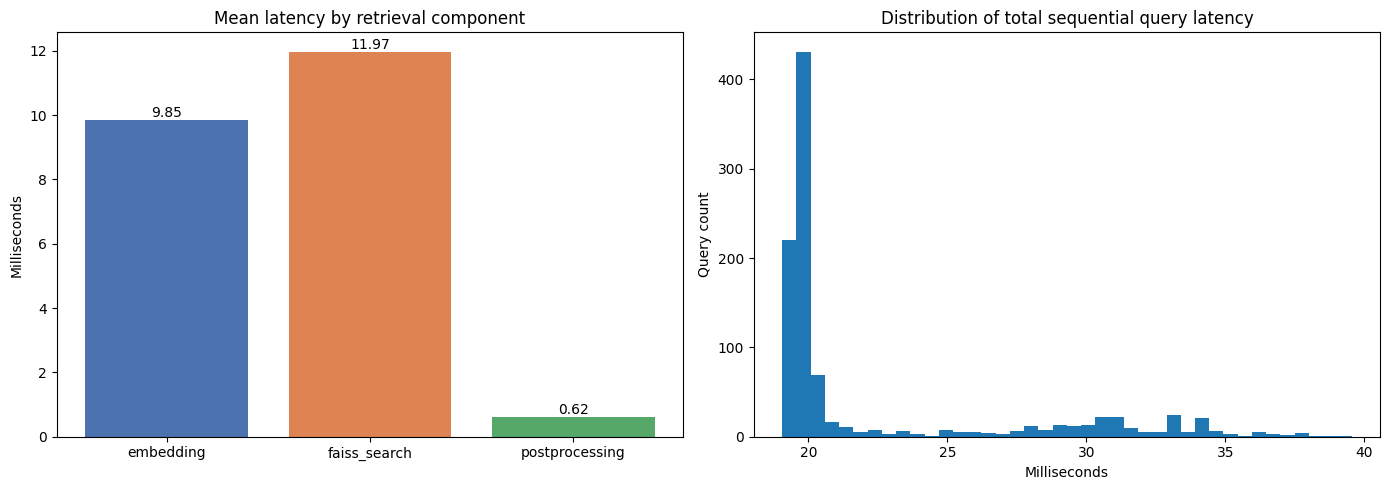

Mean component shares:
  embedding: 43.9%
  faiss_search: 53.4%
  postprocessing: 2.7%


In [13]:
components = ['embedding', 'faiss_search', 'postprocessing']
mean_component_ms = [latency_summary.loc[component, 'mean_ms'] for component in components]
total_latency_ms = np.asarray(component_timings['total']) * 1_000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(components, mean_component_ms, color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set(title='Mean latency by retrieval component', ylabel='Milliseconds')
for position, value in enumerate(mean_component_ms):
    axes[0].text(position, value, f'{value:.2f}', ha='center', va='bottom')

axes[1].hist(total_latency_ms, bins=40)
axes[1].set(title='Distribution of total sequential query latency', xlabel='Milliseconds', ylabel='Query count')

plt.tight_layout()
plt.show()

total_component_mean = sum(mean_component_ms)
print('Mean component shares:')
for component, component_time in zip(components, mean_component_ms):
    print(f'  {component}: {component_time / total_component_mean:.1%}')


## Quality and performance interpretation

The final MRR@5 and latency statistics should be read from the cells above after the current run. The result demonstrates the quality of this exact configuration: the fixed paper collection, labelled evaluation sample, BGE encoder, query instruction, CLS pooling, 512-token truncation policy, and exact CPU FAISS index.

A reranker is intentionally not included in the baseline. A cross-encoder can improve ranking quality but introduces additional inference latency. It becomes appropriate only if a measured quality gap justifies that latency trade-off.


## Stage 4 - Bottleneck analysis and acceleration options


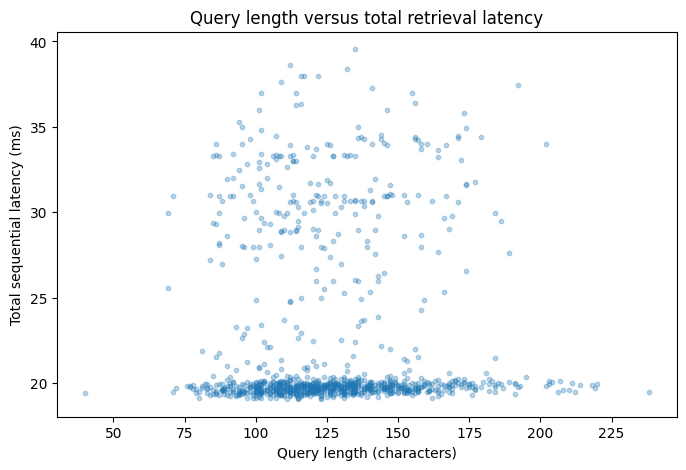

Pearson correlation between query length and total latency: -0.014


In [14]:
query_lengths = test_df['query_characters'].to_numpy()
correlation = float(np.corrcoef(query_lengths, total_latency_ms)[0, 1])

plt.figure(figsize=(8, 5))
plt.scatter(query_lengths, total_latency_ms, alpha=0.3, s=10)
plt.xlabel('Query length (characters)')
plt.ylabel('Total sequential latency (ms)')
plt.title('Query length versus total retrieval latency')
plt.show()

print(f'Pearson correlation between query length and total latency: {correlation:.3f}')


## Bottleneck interpretation and next experiments

The bar chart identifies whether query encoding or exact FAISS search is the larger contributor in this specific runtime. If exact search dominates at a larger corpus scale, compare `IndexFlatIP` with an approximate index such as HNSW or IVF while reporting both recall/MRR and latency. If embedding dominates, test batching for offline workloads, a smaller encoder, or lower-precision inference. These are hypotheses for measured comparison, not claims that they will improve this configuration.

The latency histogram may reveal runtime variability. A near-zero correlation with query character length would only show that character count does not explain a linear relationship in this run; it would not identify the operational cause of latency variation. Repeated benchmarks on fixed hardware would be needed for operational conclusions.


## Optional deployment extension - ONNX export

This section is intentionally **off by default**. It exports the CLS-pooling encoder to ONNX after baseline evaluation. Compiling the exported model with TensorRT requires a version-compatible CUDA/TensorRT environment and should be treated as a separate deployment experiment. Do not substitute its results for the baseline metric or latency values without repeating the complete evaluation.


In [ ]:
# Optional and disabled by default. Run only after the native PyTorch baseline is complete.
RUN_ONNX_EXPORT = False
ONNX_PATH = ARTIFACT_DIR / 'bge_base_en_v15_cls_encoder.onnx'

class BGECLSEncoder(torch.nn.Module):
    def __init__(self, encoder: torch.nn.Module):
        super().__init__()
        self.encoder = encoder

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )
        return F.normalize(outputs.last_hidden_state[:, 0], p=2, dim=1)

if RUN_ONNX_EXPORT:
    # Install the ONNX package in a separate cell when needed: %pip install -q onnx
    export_model = BGECLSEncoder(embedder_model).eval().to(device)
    example_inputs = embedder_tokenizer(
        ['A short query for ONNX export validation.'],
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors='pt',
    ).to(device)

    torch.onnx.export(
        export_model,
        args=(
            example_inputs['input_ids'],
            example_inputs['attention_mask'],
            example_inputs['token_type_ids'],
        ),
        f=str(ONNX_PATH),
        input_names=['input_ids', 'attention_mask', 'token_type_ids'],
        output_names=['embeddings'],
        dynamic_axes={
            'input_ids': {0: 'batch_size', 1: 'sequence_length'},
            'attention_mask': {0: 'batch_size', 1: 'sequence_length'},
            'token_type_ids': {0: 'batch_size', 1: 'sequence_length'},
            'embeddings': {0: 'batch_size'},
        },
        opset_version=17,
    )
    print(f'ONNX encoder exported to: {ONNX_PATH}')
else:
    print('ONNX export is disabled. Set RUN_ONNX_EXPORT = True only for the optional deployment experiment.')
